In [1]:
!pip install sentence-transformers seaborn matplotlib

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Write 10 sentences across exactly 3 topics: Cricket, Cooking, and Cybersecurity (at least 3 sentences per topic)

In [4]:
sentences = [
    # Cricket (4 sentences)
    "The batsman scored a century in the final match",
    "The bowler delivered a perfect yorker to take a wicket",
    "The team celebrated their victory after a thrilling chase",
    "The captain set an aggressive field for the spinner",

    # Cooking (3 sentences)
    "She added spices to enhance the flavor of the curry",
    "The chef baked a delicious chocolate cake",
    "Boiling vegetables helps retain their nutrients",
    "The chef garnished the dish beautifully before serving.",

    # Cybersecurity (3 sentences)
    "Strong passwords are essential for protecting accounts",
    "The firewall blocked unauthorized access attempts",
    "Encryption ensures data privacy over the internet",
    "The system detected a malware attack in real time."
]

Generate embeddings using sentence-transformers (all-MiniLM-L6-v2 model)

In [5]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Compute and display a 10×10 cosine similarity matrix as a heatmap

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

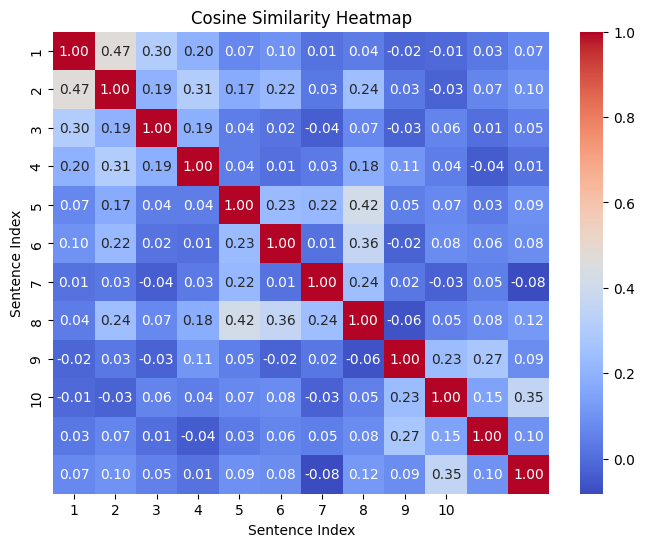

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=range(1,11),
            yticklabels=range(1,11))

plt.title("Cosine Similarity Heatmap")
plt.xlabel("Sentence Index")
plt.ylabel("Sentence Index")
plt.show()

Given this new query sentence — "The bowler took three wickets in one over" — find and print the top 2 most similar sentences from your set with their similarity scores

In [9]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

In [15]:
import numpy as np

top_indices = np.argsort(query_similarities)[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {query_similarities[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: The bowler delivered a perfect yorker to take a wicket
Similarity Score: 0.6836

Sentence: The batsman scored a century in the final match
Similarity Score: 0.5707

